In [2]:
# Standard libraries
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import matplotlib.colors as mcolors
from mpl_toolkits.axes_grid1 import make_axes_locatable
import sys, os
# Project Path Setup
from setup_project_path import check_and_add_project_path  # Script to check and add project path
check_and_add_project_path()


# Import Custom Modules
from src.utils.module_utils.all_custom_modules import cf, DataInterp, Hdf5Kernel, fit_logarithmic, log_func # Consolidated custom modules import
import src.utils.common_funcs as cf



Project path successfully added.


In [3]:
#filename_ID = f'../data/ID_delta_t=0.1_flatband_Lambda=10.h5'
filename_ID = f'../data/test_ID.h5'
#Create instance of Hdf5Kernel
h5_kernel_ID = Hdf5Kernel(filename=filename_ID)
#Extract the relevant data for plotting from hdf5 file. Assemble it conveniently into multidimensional arrays.
keys = ["eps", "m", "n", "h", "N_max", "beta", "delta_t", "ID_rank","ID_error_reconstr_vs_cont"]

#order of indices: h_vals, N_maxs, beta

kernel_dims_ID, data_h5_ID = h5_kernel_ID.read_scalars_to_array(keys=keys)

errors_discretization = data_h5_ID["eps"]
m_vals = data_h5_ID["m"] #factor 2 for positive and negative frequencies
n_vals = data_h5_ID["n"] #factor 2 for positive and negative frequencies
h_vals = data_h5_ID["h"]
N_maxs = data_h5_ID["N_max"]
betas = data_h5_ID["beta"]
delta_t_vals = data_h5_ID["delta_t"]
ID_ranks = data_h5_ID["ID_rank"]
errors_ID = data_h5_ID["ID_error_reconstr_vs_cont"]
N_modes_finegrid = 2*(m_vals + n_vals)

print(f"Errors Discretization: {errors_discretization}")
print(f"Errors ID: {errors_ID}")


Errors Discretization: [[[7.51308061e-17 6.42317664e-17]
  [7.09118011e-17 6.96180606e-17]
  [7.65762188e-17 8.01930902e-17]
  [7.71477102e-17 8.19313922e-17]
  [7.80246945e-17 8.56891107e-17]
  [7.90638774e-17 8.78744455e-17]
  [8.14105487e-17 9.19137648e-17]
  [8.40087480e-17 9.41466533e-17]
  [8.86580854e-17 9.68150944e-17]
  [1.05928363e-16 1.06054491e-16]
  [1.36326083e-16 1.21439226e-16]
  [1.90066591e-16 1.47990341e-16]
  [2.84026178e-16 1.76554782e-16]
  [5.05696855e-16 2.29995554e-16]
  [1.23237672e-15 4.27946195e-16]]

 [[8.25799748e-17 6.42969139e-17]
  [8.30618462e-17 7.28053554e-17]
  [9.11547675e-17 8.66955011e-17]
  [9.28524277e-17 8.91970790e-17]
  [9.28497492e-17 9.06842485e-17]
  [9.18512456e-17 9.29677806e-17]
  [9.20938172e-17 9.63010009e-17]
  [9.47907922e-17 9.73959265e-17]
  [9.93665981e-17 9.92408090e-17]
  [1.15394784e-16 1.07668815e-16]
  [1.42630691e-16 1.20924853e-16]
  [1.92981767e-16 1.45186174e-16]
  [2.84740575e-16 1.71726891e-16]
  [5.07358012e-16 2.239

In [45]:
filename_AAA = f'../data/AAA_delta_t=0.1_flatband_Lambda=10.h5'
#Create instance of Hdf5Kernel
h5_kernel_AAA = Hdf5Kernel(filename=filename_AAA)
#Extract the relevant data for plotting from hdf5 file. Assemble it conveniently into multidimensional arrays.
keys = ["m", "n", "h",  "beta",  "AAA_error_reconstr_vs_cont","nbr_poles_upper", "tol"]

kernel_dims_AAA, data_h5_AAA = h5_kernel_AAA.read_scalars_to_array(keys=keys)

m_vals = data_h5_AAA["m"]
n_vals = data_h5_AAA["n"]
h_vals = data_h5_AAA["h"]
betas = data_h5_AAA["beta"]
errors_AAA = data_h5_AAA["AAA_error_reconstr_vs_cont"]
nbr_poles_upper = data_h5_AAA["nbr_poles_upper"]
tol_vals = data_h5_AAA["tol"]

print(f"Dimensions of data arrays: {kernel_dims_AAA}.")
print("errors AAA ", errors_AAA)
print("nbr_poles_upper ", nbr_poles_upper)




Dimensions of data arrays: [4 3 2].
errors AAA  [[[1.40569689e-03 3.11122225e-03]
  [2.28054342e-03 3.99524054e-03]
  [2.42747246e-03 3.84526584e-03]]

 [[8.03409083e-06 1.54039930e-05]
  [1.63521617e-05 2.41788832e-05]
  [2.84553349e-05 2.60010581e-05]]

 [[1.36872523e-07 5.31509614e-08]
  [2.15082428e-07 1.29081931e-07]
  [2.89916766e-07 2.11472155e-07]]

 [[3.06329610e-09 2.90874584e-07]
  [3.73973608e-09 2.04768033e-07]
  [4.96747478e-09 1.66713905e-07]]]
nbr_poles_upper  [[[18 27]
  [18 27]
  [18 27]]

 [[24 44]
  [24 44]
  [24 44]]

 [[30 58]
  [30 58]
  [30 58]]

 [[34 69]
  [34 69]
  [34 69]]]


7.923039112200353e-12


/var/folders/cg/_38xw63s1fg5wbmw91yk0qzr0000gn/T/ipykernel_325/2315283122.py:142: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(rect=[0, 0, 1, 0.9])  # Adjust the layout to make space for the colorbars


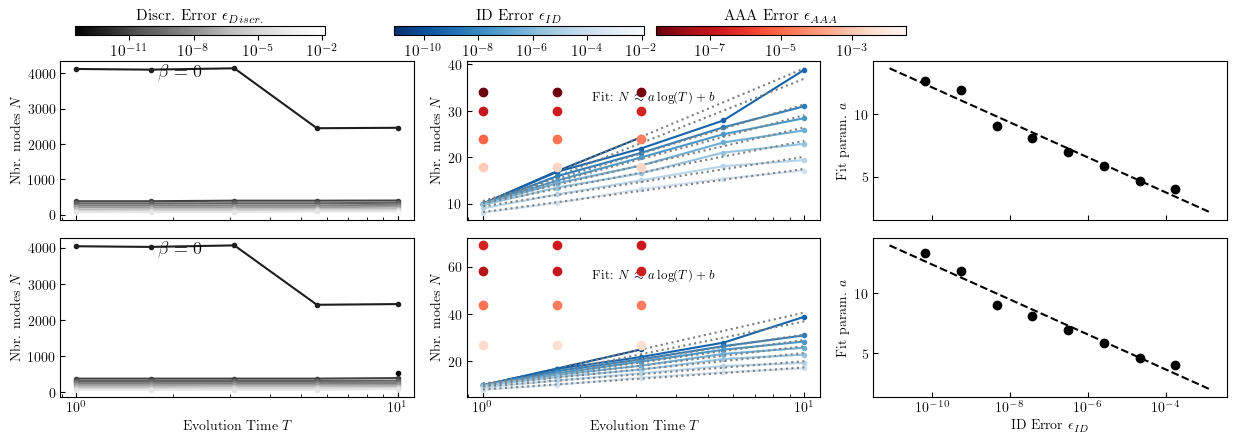

In [46]:
# Set global fontsize using rcParams

cmap_blues = plt.get_cmap("Blues_r")
cmap_reds = plt.get_cmap("Reds_r")
cmap_grays = plt.get_cmap("Greys_r")
# Configuration and data preparation
nbr_interpolations = 10

error_grid_AAA = np.logspace(np.log10(np.min(errors_AAA)), np.log10(np.max(errors_AAA)), nbr_interpolations)

#lower_bound = np.max([np.min(errors_ID), np.min(errors_discretization)])
#upper_bound = np.min([np.max(errors_ID), np.max(errors_discretization)])
print(np.min(errors_ID[:,:,1]))
#print(lower_bound, upper_bound)
#if lower_bound >= upper_bound:
#    print("Error bounds are not consistent. Please check the data.")
#    sys.exit()
#else:
error_grid_discretization = np.logspace(np.log10(np.min(errors_discretization)), np.log10(np.max(errors_discretization)), nbr_interpolations)
error_grid_ID = np.logspace(np.log10(np.min(errors_ID)), np.log10(np.max(errors_ID)), nbr_interpolations)


fig, axs = plt.subplots(kernel_dims_ID[2], 3, figsize=(12.5, 4.5))
#Set plot parameters
plt.rcParams.update({"text.usetex": True, "font.family": "serif", "font.size": 11})

N_modes_finegrid_interp = np.zeros((len(error_grid_discretization), kernel_dims_ID[1]))
ID_ranks_interp = np.zeros((len(error_grid_ID), kernel_dims_ID[1]))

t_data = np.array([np.max(N_maxs[:,tau,:] * delta_t_vals[:,tau,:]) for tau in range (kernel_dims_ID[1])])

# Use logarithmic normalization
norm_bare = mcolors.LogNorm(vmin=np.min(error_grid_discretization[error_grid_discretization > 0]), vmax=8*np.max(error_grid_discretization))
norm_AAA = mcolors.LogNorm(vmin=np.min(errors_AAA[errors_AAA > 0]), vmax=8*np.max(errors_AAA))
norm_ID = mcolors.LogNorm(vmin=np.min(errors_ID[errors_ID > 0]), vmax=8*np.max(errors_ID))


        
# Interpolation and plotting ID data
for b in range (kernel_dims_ID[2]):#loop over beta values

    fitting_params_a = np.zeros((len(error_grid_ID),))

    for tau in range (kernel_dims_ID[1]):#loop over final time values, N_max
        mask_discretization = errors_discretization[:,tau,b] > 0. # Mask to filter values clearly above machine precision
        mask_ID = errors_ID[:,tau,b] > 0. # Mask to filter values clearly above machine precision
        N_MODES_FINE_INTERP = DataInterp(errors_discretization[mask_discretization, tau,b], N_modes_finegrid[mask_discretization, tau,b])
        ID_RANKS_INTERP = DataInterp(errors_ID[mask_ID, tau,b], ID_ranks[mask_ID, tau,b])

        N_modes_finegrid_interp[:, tau] = N_MODES_FINE_INTERP.interp(error_grid_discretization, x_scale='log')
        ID_ranks_interp[:, tau] = ID_RANKS_INTERP.interp(error_grid_ID, x_scale='log')    
      
        

    for eps_iter in range(len(error_grid_discretization)):
        #plot only nonzero values
        mask_N_modes_fine = N_modes_finegrid_interp[eps_iter, :] > 0.
        mask_ID = ID_ranks_interp[eps_iter, :] > 0.
        error_bare = error_grid_discretization[eps_iter]
        error_ID = error_grid_ID[eps_iter]

        axs[b,0].plot(t_data[mask_N_modes_fine], N_modes_finegrid_interp[eps_iter, mask_N_modes_fine], marker="o", linestyle="-", markersize=3, color=cmap_grays(norm_bare(error_bare)))
        axs[b,1].plot(t_data[mask_ID], ID_ranks_interp[eps_iter, mask_ID], marker="o", linestyle="-", markersize=3, color=cmap_blues(norm_ID(error_ID)))    
        #fit logarithmic curves
        if sum(mask_ID) > 1:
            params = fit_logarithmic(t_data[mask_ID][:], ID_ranks_interp[eps_iter, mask_ID][:])
            fitting_params_a[eps_iter] = params[0]

            axs[b,1].plot(t_data[mask_N_modes_fine], log_func(t_data[mask_N_modes_fine], *params),  color="gray", linestyle = 'dotted')
        
    
            #plot fitting parameters
            axs[b,2].scatter(error_ID, params[0], marker="o",  color="black", label = r'$a$')

    for tau in range(kernel_dims_AAA[1]):
        for tol_iter, tol_val in enumerate(tol_vals[:,tau,b]):
            axs[b,1].scatter(t_data[tau], nbr_poles_upper[tol_iter, tau, b], marker="o", color=cmap_reds(norm_AAA(errors_AAA[tol_iter,tau,b])), zorder = 10)


    mask_fitting_params = fitting_params_a > 0.
    if np.sum(mask_fitting_params) > 1:
        a_fitting_params= fit_logarithmic(error_grid_ID[mask_fitting_params], fitting_params_a[mask_fitting_params])
        axs[b,2].plot(error_grid_ID, log_func(error_grid_ID,*a_fitting_params), color = 'black', linestyle = 'dashed')

    axs[b, 0].set_title(r'$\beta = 0$', loc='right', x = .4, y=0.85)
    axs[b, 1].set_title(r'$\beta = \infty$', loc='right', x = .4, y=0.85)
    axs[b, 1].set_title("Fit: "+ r'$N \approx a \log (T) + b$', loc='right', x = .7, y=0.7, fontsize = "small")
    #axs[b, 2].set_title("Fitting function: \n" + r'$y = {} \log (\epsilon) {}$'.format(*np.round(a_fitting_params,2)), loc='right', x = .9, y=0.7)
    

    axs[b,0].set_ylabel("Nbr. modes " + r"$N$")
    axs[b,1].set_ylabel("Nbr. modes " + r"$N$")
    axs[b,2].set_ylabel("Fit param. " + r'$a$')
  

    axs[b,0].set_xscale('log')
    axs[b,1].set_xscale('log')
    axs[b,2].set_xscale('log')



    
# Setting labels and legend
axs[-1,0].set_xlabel("Evolution Time " + r'$T$')
axs[-1,1].set_xlabel("Evolution Time " + r'$T$')
axs[-1,2].set_xlabel("ID Error " + r'$\epsilon_{ID}$')

# Add a colorbar for the grays above the figure
cax_grays = fig.add_axes([0.065, 0.92, 0.2, 0.02])
sm_grays = cm.ScalarMappable(cmap=cmap_grays, norm=norm_bare)
sm_grays.set_array([])
cbar_grays = fig.colorbar(sm_grays, cax=cax_grays, orientation='horizontal')
cbar_grays.set_label('Discr. Error ' + r'$\epsilon_{Discr.}$', labelpad=-35)

# Add a colorbar for the blues above the figure
cax_blues = fig.add_axes([0.32, 0.92, 0.2, 0.02])
sm_blues = cm.ScalarMappable(cmap=cmap_blues, norm=norm_ID)
sm_blues.set_array([])
cbar_blues = fig.colorbar(sm_blues, cax=cax_blues, orientation='horizontal')
cbar_blues.set_label('ID Error ' + r'$\epsilon_{ID}$', labelpad=-35)

# Add a colorbar for the reds above the figure
cax_reds = fig.add_axes([0.53, 0.92, 0.2, 0.02])
sm_reds = cm.ScalarMappable(cmap=cmap_reds, norm=norm_AAA)
sm_reds.set_array([])
cbar_reds = fig.colorbar(sm_reds, cax=cax_reds, orientation='horizontal')
cbar_reds.set_label('AAA Error ' + r'$\epsilon_{AAA}$', labelpad=-35)

#remove tick labels from upper plots
for i in range(3):
    axs[0,i].set_xticklabels([])

#move all ticks into plotting area
for ax in axs.flat:
    ax.xaxis.set_tick_params(which='both', direction='in')
    ax.yaxis.set_tick_params(which='both', direction='in')

#move lower plots closer to upper plots, such that the upper edge of the lower plots zouces with the lower edge of the upper plots. do not use subplots_adjust
fig.subplots_adjust(hspace=0.0, wspace=0.0)


plt.tight_layout(rect=[0, 0, 1, 0.9])  # Adjust the layout to make space for the colorbars


#plt.savefig("../plots/modes_vs_time_no_opt.pdf", bbox_inches='tight')


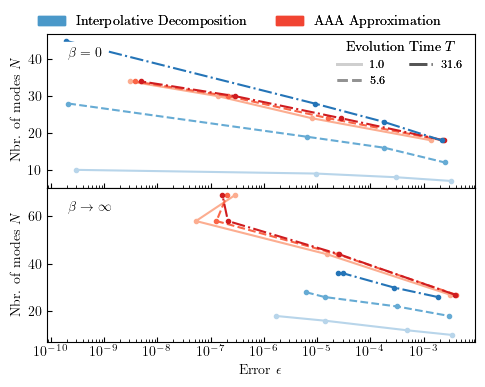

In [45]:
filename_ID = f'../data/ID_delta_t=0.1_flatband_Lambda=10.h5'
#Create instance of Hdf5Kernel
h5_kernel_ID = Hdf5Kernel(filename=filename_ID)
#Extract the relevant data for plotting from hdf5 file. Assemble it conveniently into multidimensional arrays.
keys = ["eps", "m", "n", "h", "N_max", "beta", "delta_t", "ID_rank","ID_error_reconstr_vs_cont"]

#order of indices: h_vals, N_maxs, beta

kernel_dims_ID, data_h5_ID = h5_kernel_ID.read_scalars_to_array(keys=keys)

errors_discretization = data_h5_ID["eps"]
m_vals = data_h5_ID["m"] #factor 2 for positive and negative frequencies
n_vals = data_h5_ID["n"] #factor 2 for positive and negative frequencies
h_vals = data_h5_ID["h"]
N_maxs = data_h5_ID["N_max"]
betas = data_h5_ID["beta"]
delta_t_vals = data_h5_ID["delta_t"]
ID_ranks = data_h5_ID["ID_rank"]
errors_ID = data_h5_ID["ID_error_reconstr_vs_cont"]
N_modes_finegrid = 2*(m_vals + n_vals + 1)

#print(f"Errors Discretization: {errors_discretization}")
#print(f"Errors ID: {errors_ID}")




filename_AAA = f'../data/AAA_delta_t=0.1_flatband_Lambda=10.h5'
#Create instance of Hdf5Kernel
h5_kernel_AAA = Hdf5Kernel(filename=filename_AAA)
#Extract the relevant data for plotting from hdf5 file. Assemble it conveniently into multidimensional arrays.
keys = ["m", "n", "h",  "beta",  "AAA_error_reconstr_vs_cont","nbr_poles_upper", "tol"]

kernel_dims_AAA, data_h5_AAA = h5_kernel_AAA.read_scalars_to_array(keys=keys)

m_vals = data_h5_AAA["m"]
n_vals = data_h5_AAA["n"]
h_vals = data_h5_AAA["h"]
betas = data_h5_AAA["beta"]
errors_AAA = data_h5_AAA["AAA_error_reconstr_vs_cont"]
nbr_poles_upper = data_h5_AAA["nbr_poles_upper"]
tol_vals = data_h5_AAA["tol"]

#print(f"Dimensions of data arrays: {kernel_dims_AAA}.")
#print("errors AAA ", errors_AAA)
#print("nbr_poles_upper ", nbr_poles_upper)

t_data = np.array([np.max(N_maxs[:,tau,:] * delta_t_vals[:,tau,:]) for tau in range (kernel_dims_ID[1])])


# Set global fontsize using rcParams
from itertools import cycle

# Function to generate linestyles cycler
def generate_linestyles_cycler(n):
    predefined_linestyles = ['-', '--', '-.', ':']
    return predefined_linestyles[:n]


cmap_blues = plt.get_cmap("Blues")
cmap_reds = plt.get_cmap("Reds")
cmap_grays = plt.get_cmap("Greys")

linestyles_predef = generate_linestyles_cycler(kernel_dims_ID[1])
linestyles = cycle(linestyles_predef)

linecycler = cycle(linestyles)

fig, axs = plt.subplots(2, 1, figsize=(5, 4.2), sharex=True)
#Set plot parameters
plt.rcParams.update({"text.usetex": True, "font.family": "serif", "font.size": 10})


# Collect handles and labels for the legend
handles_AAA = []
labels_AAA = []
handles_ID = []
labels_ID = []


norm_times = mcolors.LogNorm(vmin=0.1*np.min(t_data[t_data > 0]), vmax=8*np.max(t_data))

for b in range(kernel_dims_ID[2]):
    for tau in range(kernel_dims_ID[1]):
        err_AAA = []
        nbr_poles = []
        err_ID = []
        ID_modes = []

        for tol_iter in range(tol_vals.shape[0]):
            err_AAA.append(errors_AAA[tol_iter, tau, b])
            err_ID.append(errors_ID[tol_iter, tau, b])
            nbr_poles.append(nbr_poles_upper[tol_iter, tau, b])
            ID_modes.append(ID_ranks[tol_iter, tau, b])
        

        linestyle = next(linecycler)

        line_AAA, = axs[b].plot(err_AAA, nbr_poles, marker="o", linestyle=linestyle, markersize=3, 
                                color=cmap_reds(norm_times(t_data[tau])), label=r'$t = {}$'.format(round(t_data[tau], 2)))
        line_ID, = axs[b].plot(err_ID, ID_modes, marker="o", linestyle=linestyle, markersize=3, 
                               color=cmap_blues(norm_times(t_data[tau])), label=r'$t = {}$'.format(round(t_data[tau], 2)))

      
        # Collect legend handles and labels for unique time values
        
        if line_AAA.get_label() not in labels_AAA:
            handles_AAA.append(line_AAA)
            labels_AAA.append(line_AAA.get_label())
        if line_ID.get_label() not in labels_ID:
            handles_ID.append(line_ID)
            labels_ID.append(line_ID.get_label())


    axs[b].set_ylabel("Nbr. of modes " + r"$N$")
    axs[b].set_xscale("log")
 

axs[1].set_xlabel("Error " + r"$\epsilon$")

#for text inset, choose background color white
axs[0].text(0.05, 0.85, r"$\beta = 0$", transform=axs[0].transAxes, backgroundcolor='white')
axs[1].text(0.05, 0.85, r"$\beta \to \infty$", transform=axs[1].transAxes, backgroundcolor='white')

# Adjust layout to make space for the legends
plt.tight_layout(rect=[0, 0, 1, 0.9])

# Define custom legend elements for colors
from matplotlib.patches import Patch
legend_elements = [Patch(facecolor=cmap_blues(0.6), edgecolor=cmap_blues(0.6), label='Interpolative Decomposition'),
                   Patch(facecolor=cmap_reds(0.6), edgecolor=cmap_reds(0.6), label='AAA Approximation'),]

# Create custom legend
legend = plt.legend(handles=legend_elements, loc='upper center', ncol=2, bbox_to_anchor=(0.45, 2.2), fontsize='medium', frameon=False)

# Add the custom legend to the figure
fig.add_artist(legend)

#move all ticks into plot area:
for ax in axs.flat:
    ax.xaxis.set_tick_params(which='both', direction='in')
    ax.yaxis.set_tick_params(which='both', direction='in')

#create a custom legend for each linestyle in the plot: only one in shades of gray that applies to all plots
from matplotlib.lines import Line2D
legend_elements = [Line2D([0], [0], color=cmap_grays(norm_times(t_data[tau])), linestyle=linestyle, label= str(round(t_data[tau], 2)), lw=2) for tau, linestyle in enumerate(linestyles_predef)]
legend = fig.legend(handles=legend_elements, loc='upper center', ncol=2, bbox_to_anchor=(0.82, 0.87), fontsize='small', frameon=False, title = "Evolution Time " + r'$T$')
fig.add_artist(legend)

#move lower plots closer to upper plots
fig.subplots_adjust(hspace=0.0, wspace=0.0)

#move all ticks into plot area:
for ax in axs.flat:
    ax.xaxis.set_tick_params(which='both', direction='in')
    ax.yaxis.set_tick_params(which='both', direction='in')




plt.show()

In [110]:

filename_AAA_sc = f'../data/test_AAA_semicircle_no_smoothening.h5'
#Create instance of Hdf5Kernel
h5_kernel_AAA_sc = Hdf5Kernel(filename=filename_AAA_sc)

#Extract the relevant data for plotting from hdf5 file. Assemble it conveniently into multidimensional arrays.
keys_sc = ["beta", "N_max", "delta_t", "AAA_error_reconstr_vs_cont","nbr_poles_upper", "tol", "Z", "F_particle", "ID_rank_particle", "ID_rank_hole"]

kernel_dims_AAA_sc, data_h5_AAA_sc = h5_kernel_AAA_sc.read_scalars_to_array(keys=keys_sc)

errors_AAA_sc = data_h5_AAA_sc["AAA_error_reconstr_vs_cont"]
nbr_poles_upper_sc = data_h5_AAA_sc["nbr_poles_upper"]
AAA_ID_rank_particle = data_h5_AAA_sc["ID_rank_particle"]
AAA_ID_rank_holes = data_h5_AAA_sc["ID_rank_hole"]
N_maxs_sc = data_h5_AAA_sc["N_max"]
betas_sc = data_h5_AAA_sc["beta"]
delta_t_vals_sc = data_h5_AAA_sc["delta_t"]
tol_vals_sc = data_h5_AAA_sc["tol"]
Z_vals_sc = data_h5_AAA_sc["Z"]
F_vals_sc = data_h5_AAA_sc["F_particle"]


t_data = np.array([np.max(N_maxs_sc[:,tau,:] * delta_t_vals_sc[:,tau,:]) for tau in range (kernel_dims_AAA_sc[1])])

print(f"Dimensions of data arrays: {kernel_dims_AAA_sc}.")
#print("errors AAA ", errors_AAA_sc)
#print("nbr_poles_upper ", nbr_poles_upper_sc)




def get_idx(tol, tau, beta):
    return tol * kernel_dims_AAA_sc[1] *  kernel_dims_AAA_sc[2] + tau * kernel_dims_AAA_sc[2] + beta


Dimensions of data arrays: [100  10   2].


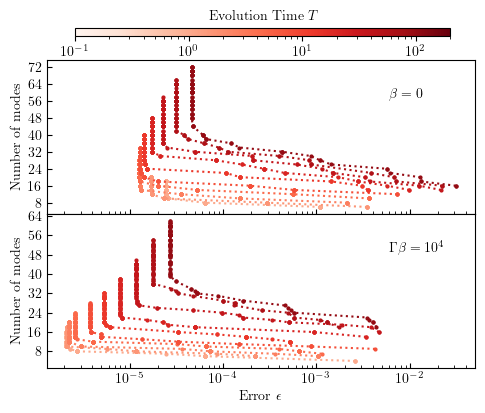

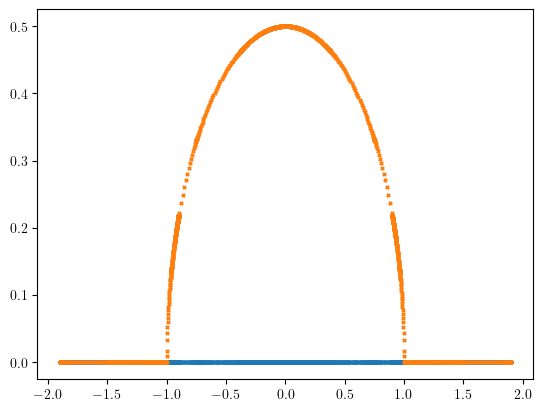

In [111]:
# Set global fontsize using rcParams
#Set plot parameters
plt.rcParams.update({"text.usetex": True, "font.family": "serif", "font.size": 10})
from itertools import cycle
cmap_reds = plt.get_cmap("Reds")
norm_times = mcolors.LogNorm(vmin=0.1*np.min(t_data[t_data > 0]), vmax=2*np.max(t_data))
fig, axs = plt.subplots(2, 1, figsize=(5, 4.2), sharex=True)

# Collect handles and labels for the legend
handles_AAA = []
labels_AAA = []


for b in range(kernel_dims_AAA_sc[2]):
    for tau in range(kernel_dims_AAA_sc[1]):
        err_AAA_sc = []
        nbr_poles_sc = []
       
        for tol_iter in range(len(tol_vals_sc[:, tau, b])):
            err_AAA_sc.append(errors_AAA_sc[tol_iter, tau, b])
            nbr_poles_sc.append(AAA_ID_rank_particle[tol_iter, tau, b] + AAA_ID_rank_holes[tol_iter, tau, b])

  
        line_AAA, = axs[b].plot(err_AAA_sc, nbr_poles_sc, marker="o", linestyle="dotted", markersize=2, 
                                color=cmap_reds(norm_times(t_data[tau])), label=r'$t = {}$'.format(round(t_data[tau], 2)))
     

        if line_AAA.get_label() not in labels_AAA:
            handles_AAA.append(line_AAA)
            labels_AAA.append(line_AAA.get_label())
      

    axs[b].set_xlabel("Error "+ r"$\epsilon$")
    axs[b].set_ylabel("Number of modes")
    axs[b].set_xscale("log")


#for text inset, choose background color white
axs[0].text(0.8, 0.75, r"$\beta = 0$", transform=axs[0].transAxes, backgroundcolor='white')
axs[1].text(0.8, 0.75, r"$  \Gamma\beta = 10^4$", transform=axs[1].transAxes, backgroundcolor='white')

# Add a single legend above the entire figure
from matplotlib.legend import Legend

# Adjust layout to make space for the legends
plt.tight_layout(rect=[0, 0, 1, 0.9])

# Create custom legends
#legend = Legend(fig, handles_AAA, labels_AAA, loc='upper center', ncol=len(t_data), fontsize='small', title="AAA (Red Curves)")
# Add the legends manually
#fig.add_artist(legend)
#legend.set_bbox_to_anchor((0.5, .95))


# Add a colorbar for the reds above the figure
cax_reds = fig.add_axes([0.17, 0.92, 0.75, 0.02])
sm_reds = cm.ScalarMappable(cmap=cmap_reds, norm=norm_times)
sm_reds.set_array([])
cbar_reds = fig.colorbar(sm_reds, cax=cax_reds, orientation='horizontal')
cbar_reds.set_label("Evolution Time " + r'$T$', labelpad=-35, fontsize='medium')

#move all ticks into plot area:
for ax in axs.flat:
    ax.xaxis.set_tick_params(which='both', direction='in')
    ax.yaxis.set_tick_params(which='both', direction='in')
    # Ensure y-axis ticks are integers
    from matplotlib.ticker import MaxNLocator
    ax.yaxis.set_major_locator(MaxNLocator(integer=True))

#move lower plots closer to upper plots
fig.subplots_adjust(hspace=0.0, wspace=0.0)
plt.show()

plt.scatter(np.array(Z_vals_sc)[0], np.zeros_like(np.array(Z_vals_sc)[0]), marker = 'o', linestyle = 'None', s = 5)
plt.scatter(np.array(Z_vals_sc)[0], np.array(F_vals_sc)[0], marker = 'x', linestyle = 'None', s = 5)
plt.show()






In [6]:
filename_AAA_sc = f'../data/test_AAA_linear2.h5'
#Create instance of Hdf5Kernel
h5_kernel_AAA_sc = Hdf5Kernel(filename=filename_AAA_sc)
keys_sc = ["beta", "N_max", "delta_t", "AAA_error_reconstr_vs_cont","nbr_poles_upper", "tol", "Z", "F_particle", "ID_rank_particle", "ID_poles_particle_upper","ID_poles_hole_upper", "poles_particle_upper", "poles_hole_upper", "ID_residues_hole_upper", "ID_residues_particle_upper", "residues_hole_upper", "residues_particle_upper", "poles_particle", "poles_hole", "residues_particle", "residues_hole"]

kernel_dims_AAA_sc, data_h5_AAA_sc = h5_kernel_AAA_sc.read_scalars_to_array(keys=keys_sc)

ID_poles_particle_upper = data_h5_AAA_sc["ID_poles_particle_upper"]
ID_poles_hole_upper = data_h5_AAA_sc["ID_poles_hole_upper"]
ID_residues_hole_upper = data_h5_AAA_sc["ID_residues_hole_upper"]
ID_residues_particle_upper = data_h5_AAA_sc["ID_residues_particle_upper"]
poles_particle_upper = data_h5_AAA_sc["poles_particle_upper"]
poles_hole_upper = data_h5_AAA_sc["poles_hole_upper"]
residues_hole_upper = data_h5_AAA_sc["residues_hole_upper"]
residues_particle_upper = data_h5_AAA_sc["residues_particle_upper"]
poles_particle = data_h5_AAA_sc["poles_particle"]
poles_hole = data_h5_AAA_sc["poles_hole"]
residues_particle = data_h5_AAA_sc["residues_particle"]
residues_hole = data_h5_AAA_sc["residues_hole"]
betas = data_h5_AAA_sc["beta"]


errors_AAA_sc = data_h5_AAA_sc["AAA_error_reconstr_vs_cont"]
N_maxs_sc = data_h5_AAA_sc["N_max"]

#print kernel dims
print(f"Dimensions of data arrays: {kernel_dims_AAA_sc}.")


Dimensions of data arrays: [100  10   2].


<>:15: SyntaxWarning: invalid escape sequence '\e'
<>:15: SyntaxWarning: invalid escape sequence '\e'
/var/folders/cg/_38xw63s1fg5wbmw91yk0qzr0000gn/T/ipykernel_1412/35311641.py:15: SyntaxWarning: invalid escape sequence '\e'
  axs[beta, tol_idx].text(0.3, 0.6, f"$\epsilon = {errors_AAA_sc[tol, tau, beta]:.1e}$", transform=axs[beta, tol_idx].transAxes,  bbox=dict(facecolor='white', alpha=0.8, edgecolor='none'))


3.8259867490245e-09
1000


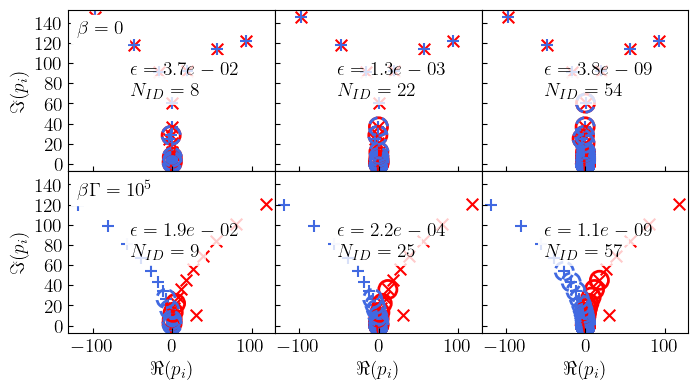

In [7]:

cmap_reds = plt.get_cmap("Reds_r")
norm_errors = mcolors.LogNorm(vmin=0.1*np.min(errors_AAA_sc[:30,:,:]), vmax=2*np.max(errors_AAA_sc[:30,:,:]))
#Set plot parameters
plt.rcParams.update({"text.usetex": True, "font.family": "serif", "font.size": 14})
#plot poles
fig, axs = plt.subplots(2, 3, figsize=(8, 4.2), sharex=True, sharey=True)

#idx axes: tol, tau, beta
tau= 9
for beta in range (2):
    for tol_idx, tol in enumerate([0,20,80]):
        idx = get_idx(tol, tau, beta)
        axs[beta, tol_idx].scatter(np.real(poles_particle_upper[idx]), np.imag(poles_particle_upper[idx]), marker = 'x', linestyle = 'None', color = 'red', s = 70)
        axs[beta, tol_idx].scatter(np.real(poles_hole_upper[idx]), np.imag(poles_hole_upper[idx]), marker = '+', linestyle = 'None', color = 'royalblue', s = 70)
        axs[beta, tol_idx].text(0.3, 0.6, f"$\epsilon = {errors_AAA_sc[tol, tau, beta]:.1e}$", transform=axs[beta, tol_idx].transAxes,  bbox=dict(facecolor='white', alpha=0.8, edgecolor='none'))
        N_ID = len(ID_poles_particle_upper[idx]) + len(ID_poles_hole_upper[idx]) #number of modes
        axs[beta, tol_idx].text(0.3, 0.47, f"$N_{{ID}} = {N_ID}$", transform=axs[beta, tol_idx].transAxes,  bbox=dict(facecolor='white', alpha=0.8, edgecolor='none'))
        axs[beta, tol_idx].scatter(np.real(ID_poles_particle_upper[idx]), np.imag(ID_poles_particle_upper[idx]), facecolors='none', edgecolors="red", linewidth = 2, linestyle = 'None', s = 170)
        axs[beta, tol_idx].scatter(np.real(ID_poles_hole_upper[idx]), np.imag(ID_poles_hole_upper[idx]), facecolors='none', edgecolors="royalblue", linewidth = 2,linestyle = 'dashed', s = 170)
       
print(errors_AAA_sc[80,9,0])
print(N_maxs_sc[80,9,1])

#move all ticks into plot area:
for ax in axs.flat:
    ax.xaxis.set_tick_params(which='both', direction='in')
    ax.yaxis.set_tick_params(which='both', direction='in')
    # Ensure y-axis ticks are integers
    from matplotlib.ticker import MaxNLocator
    ax.yaxis.set_major_locator(MaxNLocator(integer=True))
    #ax.set_xlim(-60, 60)
    #ax.set_ylim(0, 60.9)

for ax in axs[-1,:]:
    ax.set_xlabel(r"$\Re(p_i)$")
for ax in axs[:,0]:
    ax.set_ylabel(r"$\Im(p_i)$")

#write the temperature values into plots
#for text inset, choose background color white
axs[0,0].text(0.04, 0.85, r"$\beta = 0$", transform=axs[0,0].transAxes, backgroundcolor='white')
axs[1,0].text(0.04, 0.85, r"$\beta\Gamma  = 10^5$", transform=axs[1,0].transAxes, backgroundcolor='white')
    
#move lower plots closer to upper plots
fig.subplots_adjust(hspace=0.0, wspace=0.0)

Text(0.5, 0, 'Frequency $\\omega$')

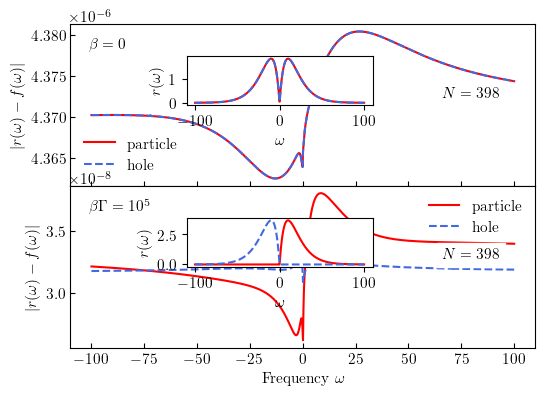

In [12]:
def rational_approximation(poles, residues, z):
    return np.sum(np.array([residue/(z[:,np.newaxis] - pole) for pole, residue in zip(poles, residues)]), axis = 0).flatten()

#use ID_poles_particle_upper, ID_residues_particle_upper, ID_poles_hole_upper, ID_residues_hole_upper
z = np.linspace(-100, 100, 1000) 

from src.spec_dens.spec_dens import spec_dens_gapless, spec_dens_semi_circle
def compare_p(z, beta_val):
    #return cf.fermi_dirac(z, -beta_val) * spec_dens_gapless(z, cutoff_lower= -20, cutoff_upper=20, sharpness=1) * abs(z)#spec_dens_semi_circle(z)
    #return  cf.fermi_dirac(z, -beta_val) * (spec_dens_gapless(z, cutoff_lower= -20, cutoff_upper=-5, sharpness=2) + spec_dens_gapless(z, cutoff_lower= 5, cutoff_upper=20, sharpness=2))
    return cf.fermi_dirac(z, -beta_val) * abs(z) * np.exp(-abs(z) / 10)
#plot
#Set plot parameters
plt.rcParams.update({"text.usetex": True, "font.family": "serif", "font.size": 11})
fig, axs = plt.subplots(2, 1, figsize=(6, 4.2), sharex=True)
for beta in [0,1]:
    beta_val = betas[0,0,beta]

    idx = get_idx(0,0,beta)#first two indices don't matter as we analyze the "bare" (uncompressed) grid which is always the same
    poles_p = poles_particle[idx]
    residues_p =  residues_particle[idx]
    poles_h = poles_hole[idx]
    residues_h =  residues_hole[idx]

    #construct rational approximation from poles and residues
    f_p = rational_approximation(poles_p, residues_p, z)
    f_h = rational_approximation(poles_h, residues_h, z)
    compare_particle = compare_p(z, beta_val)
    compare_hole = compare_p(z, -beta_val)


    axs[beta].plot(z, abs(f_p- compare_particle), label = "particle", color = "red")
    axs[beta].plot(z, abs(f_h- compare_hole), linestyle = "dashed", label = "hole", color = "royalblue")
   
    axs[beta].set_ylabel(r"$|r(\omega) - f(\omega)|$")
    axs[beta].legend(frameon = False)
    axs[beta].text(0.8, 0.55, f"$N={len(poles_p) + len(poles_h)}$", transform=axs[beta].transAxes, backgroundcolor='white')
    
    #create inset
    axin = axs[beta].inset_axes([0.25, 0.5, 0.4, 0.3])
    axin.plot(z, np.real(f_p), label = r"$r^p(\omega)$", color = "red")
    axin.plot(z, np.real(f_h), linestyle = "dashed", label = r"$r^h(\omega)$", color = "royalblue")
    axin.set_ylabel(r"$r(\omega)$")
    axin.set_xlabel(r"$\omega$")

    
#axs[0].set_ylim(1.e-10, 1.e-3)
#write the temperature values into plots
#for text inset, choose background color white
axs[0].text(0.04, 0.85, r"$\beta = 0$", transform=axs[0].transAxes, backgroundcolor='white')
axs[1].text(0.04, 0.85, r"$\beta\Gamma  = 10^5$", transform=axs[1].transAxes, backgroundcolor='white')

#move all ticks into plot area:
for ax in axs.flat:
    ax.xaxis.set_tick_params(which='both', direction='in')
    ax.yaxis.set_tick_params(which='both', direction='in')

#move lower plots closer to upper plots
fig.subplots_adjust(hspace=0.0)
axs[-1].set_xlabel("Frequency "+ r"$\omega$")

nbr. additional poles 0
nbr. explicit poles 12


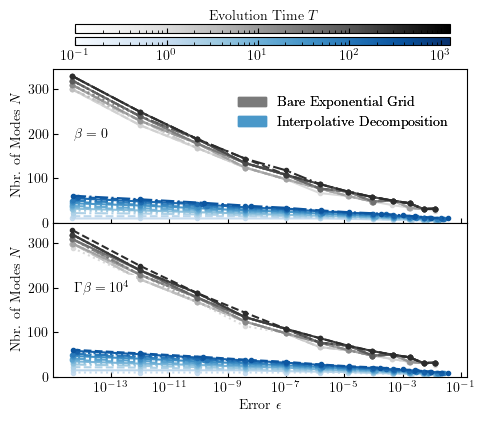

In [55]:
#filename_ID = f'../data/test_ID_Lambda50.h5'
filename_ID = f'../data/test_ID_Lambda100000_opt.h5'
#Create instance of Hdf5Kernel
h5_kernel_ID = Hdf5Kernel(filename=filename_ID)

#Extract the relevant data for plotting from hdf5 file. Assemble it conveniently into multidimensional arrays.
keys = ["eps", "m", "n", "h", "N_max", "beta", "delta_t", "ID_rank","ID_error_reconstr_vs_cont", "only_positive_particle", "additional_poles", "explicit_poles"]

cmap_blues = plt.get_cmap("Blues")
cmap_reds = plt.get_cmap("Reds")
cmap_grays = plt.get_cmap("Greys")
#order of indices: h_vals, N_maxs, beta

kernel_dims_ID, data_h5_ID = h5_kernel_ID.read_scalars_to_array(keys=keys)


errors_discretization = data_h5_ID["eps"]
nbr_additional_poles = np.array(data_h5_ID["additional_poles"]).shape[1]
nbr_explicit_poles = np.array(data_h5_ID["explicit_poles"]).shape[1]
print("nbr. additional poles", nbr_additional_poles)
print("nbr. explicit poles", nbr_explicit_poles)
m_vals = data_h5_ID["m"] 
n_vals = data_h5_ID["n"]
h_vals = data_h5_ID["h"]
N_maxs = data_h5_ID["N_max"]
betas = data_h5_ID["beta"]
delta_t_vals = data_h5_ID["delta_t"]
ID_ranks = data_h5_ID["ID_rank"]
errors_ID = data_h5_ID["ID_error_reconstr_vs_cont"]
N_modes_finegrid = ((m_vals + n_vals) + 1) + nbr_explicit_poles/2


t_data = np.array([np.max(N_maxs[:,tau,:] * delta_t_vals[:,tau,:]) for tau in range (kernel_dims_ID[1])])

# Set global fontsize using rcParams
from itertools import cycle

# Function to generate linestyles cycler
def generate_linestyles_cycler(n):
    predefined_linestyles = ['-', '--', '-.', ':']
    return cycle(predefined_linestyles[:n])

linestyles = generate_linestyles_cycler(kernel_dims_ID[1])
linecycler = cycle(linestyles)

fig, axs = plt.subplots(2, 1, figsize=(5, 4.2), sharex=True)
#Set plot parameters
plt.rcParams.update({"text.usetex": True, "font.family": "serif", "font.size": 10})

# Collect handles and labels for the legend
handles_ID = []
labels_ID = []
handles_bare = []
labels_bare = []

norm_times = mcolors.LogNorm(vmin=0.1 * np.min(t_data[t_data > 0]), vmax=4*np.max(t_data))

for b in range(kernel_dims_ID[2]):
    for tau in range(kernel_dims_ID[1]):

        err_ID = []
        ID_modes = []
        err_disc = []
        nbr_bare_modes = []
        
        for iter in range (errors_ID.shape[0]):
            err_ID.append(errors_ID[iter, tau, b])
            err_disc.append(errors_discretization[iter, tau, b])
            ID_modes.append(ID_ranks[iter, tau, b])
            nbr_bare_modes.append(N_modes_finegrid[iter, tau, b])

        #convert arrays to numpy arrays
        err_ID = np.array(err_ID)
        ID_modes = np.array(ID_modes)
        err_disc = np.array(err_disc)
        nbr_bare_modes = np.array(nbr_bare_modes)

        linestyle = next(linecycler)
        mask_ID = err_ID > 4.e-15

        line_ID, = axs[b].plot(err_ID[mask_ID], ID_modes[mask_ID], marker="o", linestyle=linestyle, markersize=3, 
                               color=cmap_blues(norm_times(t_data[tau])))


        mask_bare = err_disc > 4.e-15
        #+ np.array(np.sum(mask_bare) * [nbr_additional_poles])
        line_bare, = axs[b].plot(err_disc[mask_bare], nbr_bare_modes[mask_bare] , marker="o", linestyle=linestyle, markersize=3, color=cmap_grays(norm_times(t_data[tau])), 
                          label= str(round(t_data[tau], 2)))

        # Collect legend handles and labels for unique time values
        if line_bare.get_label() not in labels_bare:
            handles_bare.append(line_bare)
            labels_bare.append(line_bare.get_label())


    
    axs[b].set_ylabel("Nbr. of Modes " + r"$N$")
    axs[b].set_xscale("log")
    axs[b].set_ylim(bottom=0)

axs[1].set_xlabel("Error " + r"$\epsilon$")
#for text inset, choose background color white
axs[0].text(0.05, 0.55, r"$\beta = 0$", transform=axs[0].transAxes, backgroundcolor='white')
axs[1].text(0.05, 0.55, r"$\Gamma\beta  = 10^4$", transform=axs[1].transAxes, backgroundcolor='white')

# Add a single legend above the entire figure
from matplotlib.legend import Legend


# Adjust layout to make space for the legends
plt.tight_layout(rect=[0, 0, 1, 0.9])


# Define custom legend elements for colors
from matplotlib.patches import Patch
legend_elements = [Patch(facecolor=cmap_grays(0.6), edgecolor=cmap_grays(0.6), label='Bare Exponential Grid'),
                   Patch(facecolor=cmap_blues(0.6), edgecolor=cmap_blues(0.6), label='Interpolative Decomposition'),
                     ]

# Create custom legend
legend = plt.legend(handles=legend_elements, loc='upper center', ncol=1, bbox_to_anchor=(0.7, 1.9), fontsize='medium', frameon=False)

# Add the custom legend to the figure
fig.add_artist(legend)

# Adjust layout to make space for the legends
plt.tight_layout(rect=[0, 0, 1, 0.9])

# Add a colorbar for the reds above the figure
cax_grays = fig.add_axes([0.17, .95, 0.75, 0.02])
sm_grays = cm.ScalarMappable(cmap=cmap_grays, norm=norm_times)
sm_grays.set_array([])
cbar_grays = fig.colorbar(sm_grays, cax=cax_grays, orientation='horizontal')
cbar_grays.set_label("Evolution Time " + r'$T$', labelpad=-20, fontsize='medium')
# Suppress the tick labels of the red colorbar
cbar_grays.ax.set_xticklabels([])
# Place ticks inside the red colorbar
cbar_grays.ax.tick_params(axis='x', which='both', direction='in')

# Add a colorbar for the blues above the figure, but without a label
cax_blues = fig.add_axes([0.17, 0.92, 0.75, 0.02])
sm_blues = cm.ScalarMappable(cmap=cmap_blues, norm=norm_times)
sm_blues.set_array([])
cbar_blues = fig.colorbar(sm_blues, cax=cax_blues, orientation='horizontal')
# Place ticks inside the blue colorbar
cbar_blues.ax.tick_params(axis='x', which='both', direction='in')

# Ensure the colorbars are aligned and share the same title
cbar_reds.ax.xaxis.set_label_position('top')
cbar_blues.ax.xaxis.set_label_position('top')


#move all ticks into plot area:
for ax in axs.flat:
    ax.xaxis.set_tick_params(which='both', direction='in')
    ax.yaxis.set_tick_params(which='both', direction='in')

#move lower plots closer to upper plots
fig.subplots_adjust(hspace=0.0, wspace=0.0)

# Save the figure as a PDF
plt.savefig('../plots/flatband_error_Lambda=100000_pos.pdf', format='pdf', bbox_inches='tight')


Errors Discretization: [[[1.25433779e-16 1.00880901e-16]
  [1.20794230e-16 9.15757695e-17]
  [1.18567284e-16 9.63780278e-17]
  [1.15548311e-16 9.95897619e-17]
  [1.10559757e-16 9.91610307e-17]
  [1.10460173e-16 9.91403591e-17]
  [1.08443016e-16 9.91079781e-17]
  [1.07335312e-16 9.94320675e-17]
  [1.06937956e-16 9.91803733e-17]
  [1.07112536e-16 9.98937116e-17]
  [1.06607940e-16 1.00689977e-16]
  [1.05474645e-16 1.01345465e-16]
  [1.08518089e-16 1.05035079e-16]
  [1.21355752e-16 1.12565945e-16]
  [1.46977763e-16 1.23575350e-16]]

 [[1.47783124e-16 1.43943268e-16]
  [1.40410263e-16 1.33480508e-16]
  [1.38620539e-16 1.31565243e-16]
  [1.32930916e-16 1.30780786e-16]
  [1.25847662e-16 1.29202408e-16]
  [1.22796730e-16 1.25388938e-16]
  [1.19057765e-16 1.22751020e-16]
  [1.18077382e-16 1.21969280e-16]
  [1.16644766e-16 1.20769568e-16]
  [1.15752980e-16 1.19746049e-16]
  [1.14805997e-16 1.18886764e-16]
  [1.13288345e-16 1.18621395e-16]
  [1.15738077e-16 1.20912479e-16]
  [1.27813505e-16 1.273

/var/folders/cg/_38xw63s1fg5wbmw91yk0qzr0000gn/T/ipykernel_22465/563814462.py:153: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(rect=[0, 0, 1, 0.9])  # Adjust the layout to make space for the colorbars


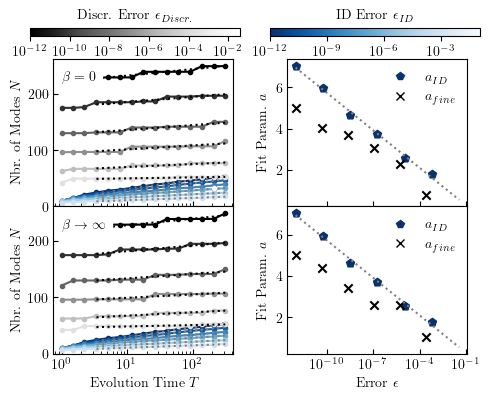

In [56]:
#filename_ID = f'../data/ID_delta_t=0.1_flatband_Lambda=10.h5'
#filename_ID = f'../data/test_ID_Lambda50_T=1e8.h5'
filename_ID = f'../data/test_ID_Lambda100000_opt.h5'
#Create instance of Hdf5Kernel
h5_kernel_ID = Hdf5Kernel(filename=filename_ID)

#Set plot parameters
plt.rcParams.update({"text.usetex": True, "font.family": "serif", "font.size": 10})
#Extract the relevant data for plotting from hdf5 file. Assemble it conveniently into multidimensional arrays.
keys = ["eps", "m", "n", "h", "N_max", "beta", "delta_t", "ID_rank","ID_error_reconstr_vs_cont", "explicit_poles"]

#order of indices: h_vals, N_maxs, beta

kernel_dims_ID, data_h5_ID = h5_kernel_ID.read_scalars_to_array(keys=keys)

errors_discretization = data_h5_ID["eps"]
m_vals = data_h5_ID["m"] #factor 2 for positive and negative frequencies
n_vals = data_h5_ID["n"] #factor 2 for positive and negative frequencies
h_vals = data_h5_ID["h"]
N_maxs = data_h5_ID["N_max"]
betas = data_h5_ID["beta"]
delta_t_vals = data_h5_ID["delta_t"]
ID_ranks = data_h5_ID["ID_rank"]
errors_ID = data_h5_ID["ID_error_reconstr_vs_cont"]
nbr_explicit_poles = np.array(data_h5_ID["explicit_poles"]).shape[1]
N_modes_finegrid = (m_vals + n_vals) + 1 + nbr_explicit_poles / 2 #factor 1/2 because here we consider only positive frequencies

print(f"Errors Discretization: {errors_discretization}")
print(f"Errors ID: {errors_ID}")


# Set global fontsize using rcParams

cmap_blues = plt.get_cmap("Blues_r")
cmap_grays = plt.get_cmap("Greys_r")
# Configuration and data preparation
nbr_interpolations = 7

#smallest nonzero error
error_min_discr = np.min(errors_discretization[errors_discretization > 0])
error_min_ID = np.min(errors_ID[errors_ID > 0])

error_grid_discretization = np.logspace(np.log10(np.max([error_min_discr,1.e-12])), np.log10(np.max(errors_discretization)), nbr_interpolations)
error_grid_ID = np.logspace(np.log10(np.max([error_min_ID,1.e-12])), np.log10(np.max(errors_ID)), nbr_interpolations)


fig, axs = plt.subplots(kernel_dims_ID[2], 2, figsize=(5, 4), sharex='col')
#Set plot parameters
plt.rcParams.update({"text.usetex": True, "font.family": "serif", "font.size": 10})

N_modes_finegrid_interp = np.zeros((len(error_grid_discretization), kernel_dims_ID[1]))
ID_ranks_interp = np.zeros((len(error_grid_ID), kernel_dims_ID[1]))

t_data = np.array([np.max(N_maxs[:,tau,:] * delta_t_vals[:,tau,:]) for tau in range (kernel_dims_ID[1])])

# Use logarithmic normalization
norm_bare = mcolors.LogNorm(vmin=error_grid_discretization[0], vmax=3*error_grid_discretization[-1])
norm_ID = mcolors.LogNorm(vmin=error_grid_ID[0], vmax=3*error_grid_ID[-1])


        
# Interpolation and plotting ID data
for b in range (kernel_dims_ID[2]):#loop over beta values

    fitting_params_a_ID = np.zeros((len(error_grid_ID),))
    fitting_params_a_bare = np.zeros((len(error_grid_discretization),))

    for tau in range (kernel_dims_ID[1]):#loop over final time values, N_max
        mask_ID = errors_ID[:,tau,b] > 0. # Mask to filter values clearly above machine precision
        ID_RANKS_INTERP = DataInterp(errors_ID[mask_ID, tau,b], ID_ranks[mask_ID, tau,b])
        ID_ranks_interp[:, tau] = ID_RANKS_INTERP.interp(error_grid_ID, x_scale='log')    
      
        mask_discretization = errors_discretization[:,tau,b] > 0. # Mask to filter values clearly above machine precision
        N_MODES_FINE_INTERP = DataInterp(errors_discretization[mask_discretization, tau,b], N_modes_finegrid[mask_discretization, tau,b])
        N_modes_finegrid_interp[:, tau] = N_MODES_FINE_INTERP.interp(error_grid_discretization, x_scale='log')
       
        

    for eps_iter in range(len(error_grid_discretization)):
        #plot only nonzero values
        mask_N_modes_fine = N_modes_finegrid_interp[eps_iter, :] > 0.
        mask_ID = ID_ranks_interp[eps_iter, :] > 0.
        error_bare = error_grid_discretization[eps_iter]
        error_ID = error_grid_ID[eps_iter]

        axs[b,0].plot(t_data[mask_N_modes_fine], N_modes_finegrid_interp[eps_iter, mask_N_modes_fine], marker="o", linestyle="-", markersize=3, color=cmap_grays(norm_bare(error_bare)))
        axs[b,0].plot(t_data[mask_ID], ID_ranks_interp[eps_iter, mask_ID], marker="o", linestyle="-", markersize=3, color=cmap_blues(norm_ID(error_ID)))    
        #fit logarithmic curves
        if sum(mask_ID) > 1:
            params_ID = fit_logarithmic(t_data[mask_ID][:], ID_ranks_interp[eps_iter, mask_ID][:])
            params_bare = fit_logarithmic(t_data[mask_N_modes_fine][1:], N_modes_finegrid_interp[eps_iter, mask_N_modes_fine][1:])
            fitting_params_a_ID[eps_iter] = params_ID[0]
            fitting_params_a_bare[eps_iter] = params_bare[0]

            #fit of log function
            axs[b,0].plot(t_data[mask_N_modes_fine][3:], log_func(t_data[mask_N_modes_fine][3:], *params_ID),  color="gray", linestyle = 'dotted')
            axs[b,0].plot(t_data[mask_ID][3:], log_func(t_data[mask_ID][3:], *params_bare),  color="black", linestyle = 'dotted')
    
            #plot fitting parameters
            axs[b,1].scatter(error_ID, params_ID[0], marker="p",  color=cmap_blues(1))
            axs[b,1].scatter(error_bare, params_bare[0], marker="x",  color=cmap_grays(1))



    mask_fitting_params = fitting_params_a_ID > 0.
    if np.sum(mask_fitting_params) > 1:
        a_fitting_params= fit_logarithmic(error_grid_ID[mask_fitting_params], fitting_params_a_ID[mask_fitting_params])
        axs[b,1].plot(error_grid_ID, log_func(error_grid_ID,*a_fitting_params), color = "gray", linestyle = 'dotted')

    # Adding a custom legend point
    from matplotlib.lines import Line2D
    custom_line_blue = Line2D([0], [0], color=cmap_blues(1), marker='p', linestyle='None')
    custom_line_gray = Line2D([0], [0], color=cmap_grays(1), marker='x', linestyle='None')
    axs[b,1].legend([custom_line_blue, custom_line_gray], [r'$a_{ID}$', r'$a_{fine}$'], loc='best', frameon=False)
    axs[b,0].set_ylabel("Nbr. of Modes " + r"$N$")
    axs[b,1].set_ylabel("Fit Param. " + r'$a$')
  

    axs[b,0].set_xscale('log')
    axs[b,1].set_xscale('log')

    axs[b,0].set_ylim(bottom=0)


#for text inset, choose background color white
axs[0,0].text(0.05, 0.85, r"$\beta = 0$", transform=axs[0,0].transAxes, backgroundcolor='white')
axs[1,0].text(0.05, 0.85, r"$\beta \to \infty$", transform=axs[1,0].transAxes, backgroundcolor='white')
# Setting labels and legend
axs[-1,0].set_xlabel("Evolution Time " + r'$T$')
axs[-1,1].set_xlabel("Error " + r'$\epsilon$')

# Add a colorbar for the grays above the figure
cax_grays = fig.add_axes([0.07, 0.92, 0.42, 0.02])
sm_grays = cm.ScalarMappable(cmap=cmap_grays, norm=norm_bare)
sm_grays.set_array([])
cbar_grays = fig.colorbar(sm_grays, cax=cax_grays, orientation='horizontal')
cbar_grays.set_label('Discr. Error ' + r'$\epsilon_{Discr.}$', labelpad=-35, fontsize='medium')

# Add a colorbar for the blues above the figure
cax_blues = fig.add_axes([0.55, 0.92, 0.42, 0.02])
sm_blues = cm.ScalarMappable(cmap=cmap_blues, norm=norm_ID)
sm_blues.set_array([])
cbar_blues = fig.colorbar(sm_blues, cax=cax_blues, orientation='horizontal')
cbar_blues.set_label("ID Error " + r'$\epsilon_{ID}$', labelpad=-35, fontsize='medium')



#move all ticks into plotting area
for ax in axs.flat:
    ax.xaxis.set_tick_params(which='both', direction='in')
    ax.yaxis.set_tick_params(which='both', direction='in')

plt.tight_layout(rect=[0, 0, 1, 0.9])  # Adjust the layout to make space for the colorbars

#move lower plots closer to upper plots, such that the upper edge of the lower plots zouces with the lower edge of the upper plots. do not use subplots_adjust
fig.subplots_adjust(hspace=0.0, wspace=.3)

# Save the figure as a PDF
plt.savefig('../plots/flatband_time_dependence_Lambda100000_pos.pdf', format='pdf', bbox_inches='tight')
